In [2]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

c:\Users\weron\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")

file_path = os.path.join(path, "btcusd_1-min_data.csv")

df = pd.read_csv(file_path)

print(df.head())

100%|██████████| 101M/101M [00:10<00:00, 10.0MB/s] 

Extracting files...


      Timestamp  Open  High   Low  Close  Volume
0  1.325412e+09  4.58  4.58  4.58   4.58     0.0
1  1.325412e+09  4.58  4.58  4.58   4.58     0.0
2  1.325412e+09  4.58  4.58  4.58   4.58     0.0
3  1.325412e+09  4.58  4.58  4.58   4.58     0.0
4  1.325412e+09  4.58  4.58  4.58   4.58     0.0


In [19]:
print(df.shape, df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7476160 entries, 0 to 7476159
Data columns (total 7 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Timestamp  datetime64[ns]
 1   Open       float64       
 2   High       float64       
 3   Low        float64       
 4   Close      float64       
 5   Volume     float64       
 6   return     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 399.3 MB
(7476160, 7) None


In [5]:
df.isna().any()

Timestamp    False
Open         False
High         False
Low          False
Close        False
Volume       False
dtype: bool

In [6]:
sum(df["Close"]<0)

0

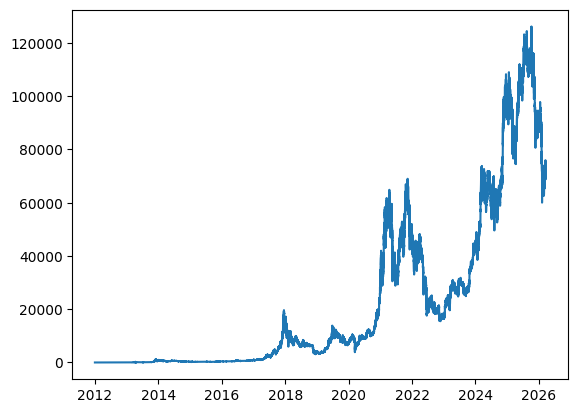

In [7]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"], unit="s")
plt.plot(df['Timestamp'], df['Close'])
plt.show()
# df['Close']=np.log(df['Close'])
# plt.plot(df['Timestamp'], df['Close'])
plt.show()

In [8]:
df["return"] = df["Close"].pct_change().shift(-1)
df.dropna()

,Timestamp,Open,High,Low,Close,Volume,return
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.000000,0.000000
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.000000,0.000000
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.000000,0.000000
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.000000,0.000000
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.000000,0.000000
...,...,...,...,...,...,...,...
7476154,2026-03-20 23:55:00,70485.00,70500.00,70485.00,70500.00,0.638203,0.000014
7476155,2026-03-20 23:56:00,70505.00,70505.00,70501.00,70501.00,0.004875,-0.000085
7476156,2026-03-20 23:57:00,70505.00,70505.00,70495.00,70495.00,0.054476,0.000227
7476157,2026-03-20 23:58:00,70495.00,70511.00,70495.00,70511.00,0.196376,-0.000128


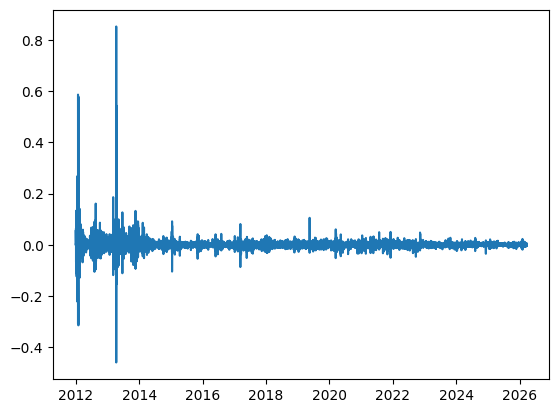

In [9]:
plt.plot(df['Timestamp'], df['return'])

In [10]:
df["return"] = df["return"].clip(-0.2, 0.2)

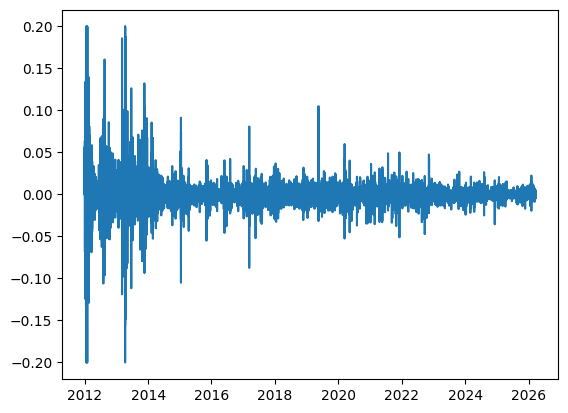

In [11]:
plt.plot(df['Timestamp'],df['return'])

In [12]:
print("mean of returns is equal", df["return"].mean(), " what is quite near to zero, \nstandard deviation is equal", df["return"].std(), "what is quite small and far from one, \nso after split data sets will be standardized")

mean of returns is equal 2.6830301243682183e-06  what is quite near to zero, 
standard deviation is equal 0.0017150999838439222 what is quite small and far from one, 
so after split data sets will be standardized


In [13]:
split = int( len(df) * 0.8)
df.drop(columns=["Open",  "High",   "Low",  "Close",  "Volume"])
df_train = df[:split]
df_test = df[split:]

mu = df_train['return'].mean()
std = df_train['return'].std()

df_train['return'] = (df_train['return']-mu)/std
df_test['return'] = (df_test['return']-mu)/std

C:\Users\weron\AppData\Local\Temp\ipykernel_18980\3125570185.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['return'] = (df_train['return']-mu)/std
C:\Users\weron\AppData\Local\Temp\ipykernel_18980\3125570185.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['return'] = (df_test['return']-mu)/std


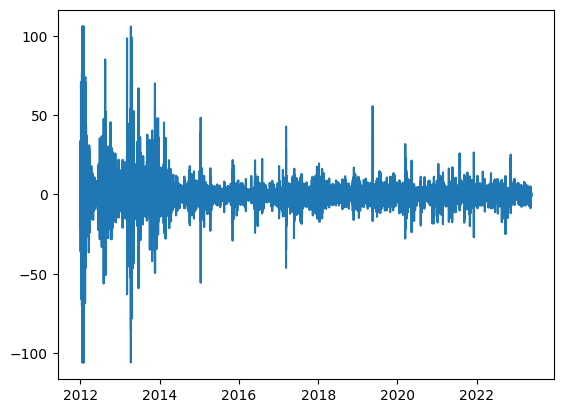

In [14]:
plt.plot(df_train['Timestamp'],df_train['return'])

In [15]:
df_train["volatility_10"] = df_train["return"].rolling(60*12).std()
df_train["return_mean_10"] = df_train["return"].rolling(60*12).mean()

C:\Users\weron\AppData\Local\Temp\ipykernel_18980\4093467364.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["volatility_10"] = df_train["return"].rolling(60*12).std()
C:\Users\weron\AppData\Local\Temp\ipykernel_18980\4093467364.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["return_mean_10"] = df_train["return"].rolling(60*12).mean()


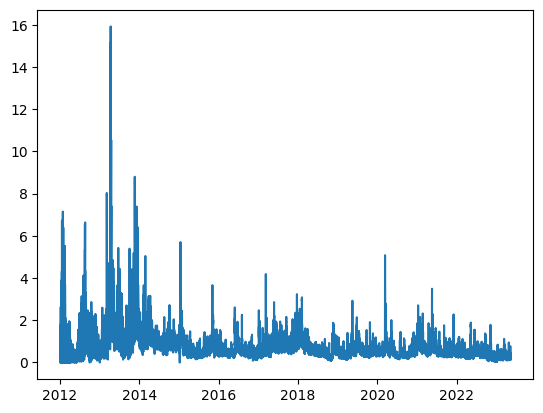

In [16]:
plt.plot(df_train["Timestamp"], df_train["volatility_10"])

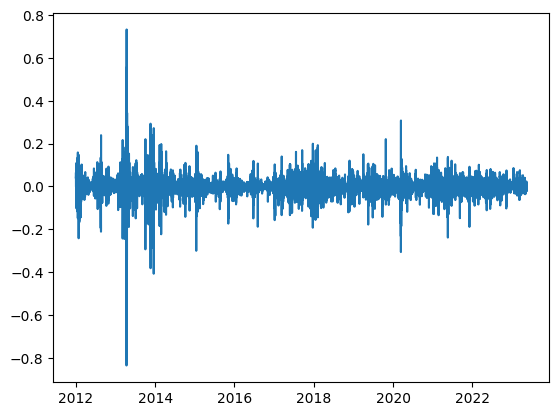

In [17]:
plt.plot(df_train["Timestamp"], df_train["return_mean_10"])

In [18]:
df.to_csv("bitcoin_processed.csv", index=False)